<a href="https://colab.research.google.com/github/agungtrisutaji/Eksperimen_SML_Agung_Trisutaji_Aprian/blob/main/Template_Eksperimen_MSML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Perkenalan Dataset**

Notebook ini menggunakan dataset **Telco Customer Churn** dari Kaggle `blastchar/telco-customer-churn`. Dataset ini berisi informasi pelanggan perusahaan telekomunikasi, seperti jenis layanan, kontrak, biaya bulanan, lama berlangganan, dan status churn.

Tujuan eksperimen adalah membangun pemahaman awal dan preprocessing untuk masalah **binary classification**, yaitu memprediksi apakah pelanggan akan churn atau tidak. Kolom target yang digunakan adalah `Churn`, dengan nilai `No` dan `Yes`.

Dataset dimuat dari path relatif repository:

```text
telco_customer_churn_raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
```

Preprocessing produksi yang reproducible tersedia di:

```text
Membangun_model/telco_customer_churn_preprocessing/preprocess.py
```

# **2. Import Library**

Tahap ini mengimpor library utama untuk analisis data, visualisasi, validasi dataset, dan preprocessing menggunakan scikit-learn. Semua path menggunakan `pathlib.Path` agar kompatibel di Windows, WSL, dan GitHub Actions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
DATA_PATH = ROOT / "telco_customer_churn_raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
PRODUCTION_PREPROCESS_SCRIPT = ROOT / "Membangun_model" / "telco_customer_churn_preprocessing" / "preprocess.py"

print(f"Repository root: {ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Python target: 3.11")

Repository root: D:\Learn\Dicoding\Pijak\Membangun Sistem Machine Learning\submission\Eksperimen_SML_Agung_Trisutaji_Aprian
Dataset path: D:\Learn\Dicoding\Pijak\Membangun Sistem Machine Learning\submission\Eksperimen_SML_Agung_Trisutaji_Aprian\telco_customer_churn_raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
Python target: 3.11


# **3. Memuat Dataset**

Dataset dibaca dari CSV yang berada di dalam struktur repository. Pada tahap ini dilakukan pemeriksaan awal menggunakan `head`, `info`, `describe`, dan `shape` untuk memahami ukuran data, kolom, tipe data awal, serta ringkasan statistik numerik.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset tidak ditemukan di: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("df.shape:", df.shape)
print("\ndf.head():")
display(df.head())

print("\ndf.info():")
df.info()

print("\ndf.describe():")
display(df.describe())

print("\nDaftar kolom:")
display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values}))

df.shape: (7043, 21)

df.head():


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nul

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Daftar kolom:


,column,dtype
0,customerID,object
1,gender,object
2,SeniorCitizen,int64
3,Partner,object
4,Dependents,object
5,tenure,int64
6,PhoneService,object
7,MultipleLines,object
8,InternetService,object
9,OnlineSecurity,object


# **4. Exploratory Data Analysis (EDA)**

Pada tahap EDA, dataset diperiksa lebih lanjut untuk melihat missing value, duplikasi, tipe data, distribusi target, pola fitur numerik, dan pola fitur kategorikal penting. Kolom `TotalCharges` dikonversi ke numerik untuk analisis karena pada dataset mentah kolom ini dapat terbaca sebagai teks.

Missing value sebelum konversi TotalCharges:


,missing_count


Missing value setelah konversi TotalCharges:


,missing_count
TotalCharges,11


Jumlah duplikasi baris: 0
Tipe data setelah TotalCharges dikonversi:


,column,dtype
0,customerID,object
1,gender,object
2,SeniorCitizen,int64
3,Partner,object
4,Dependents,object
5,tenure,int64
6,PhoneService,object
7,MultipleLines,object
8,InternetService,object
9,OnlineSecurity,object


Distribusi target Churn:


,count,percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


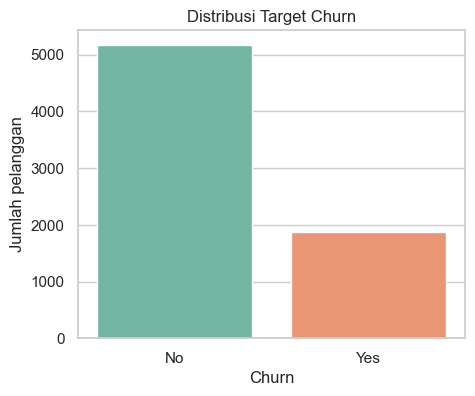

In [3]:
df_eda = df.copy()

missing_before_conversion = df_eda.isna().sum().sort_values(ascending=False)
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")
missing_after_conversion = df_eda.isna().sum().sort_values(ascending=False)
duplicate_count = df_eda.duplicated().sum()

print("Missing value sebelum konversi TotalCharges:")
display(missing_before_conversion[missing_before_conversion > 0].to_frame("missing_count"))

print("Missing value setelah konversi TotalCharges:")
display(missing_after_conversion[missing_after_conversion > 0].to_frame("missing_count"))

print(f"Jumlah duplikasi baris: {duplicate_count}")

print("Tipe data setelah TotalCharges dikonversi:")
display(pd.DataFrame({"column": df_eda.columns, "dtype": df_eda.dtypes.astype(str).values}))

target_distribution = pd.DataFrame({
    "count": df_eda["Churn"].value_counts(),
    "percentage": df_eda["Churn"].value_counts(normalize=True).mul(100).round(2),
})
print("Distribusi target Churn:")
display(target_distribution)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df_eda, x="Churn", hue="Churn", palette="Set2", legend=False, ax=ax)
ax.set_title("Distribusi Target Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Jumlah pelanggan")
plt.show()

Ringkasan statistik fitur numerik utama:


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


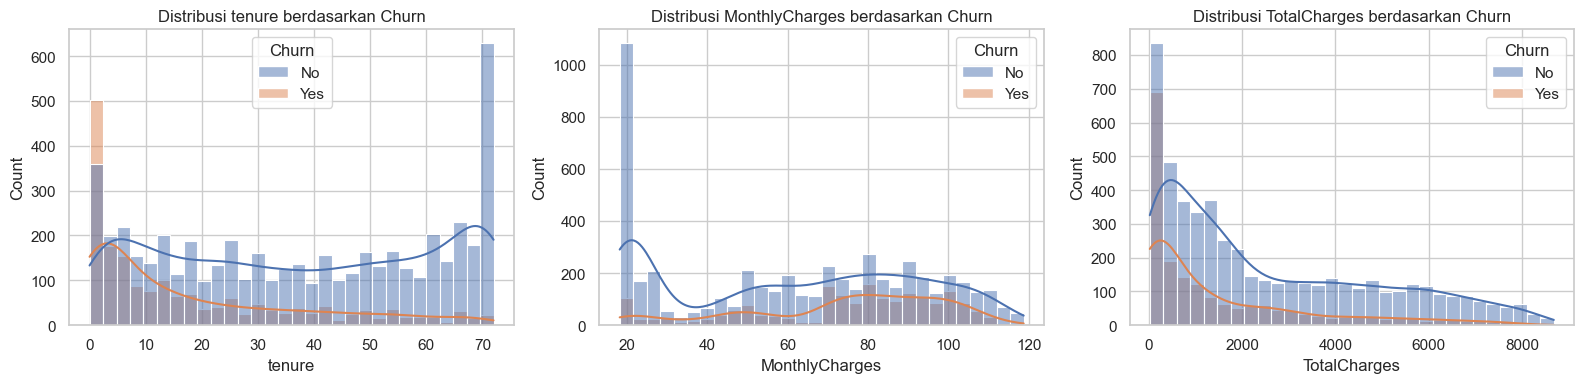

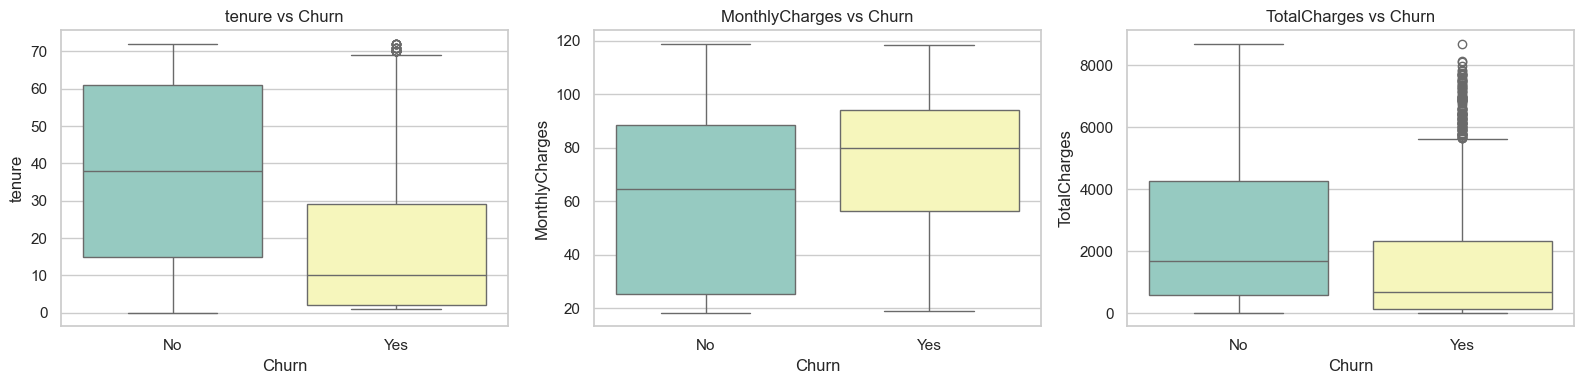

In [4]:
numeric_features_for_eda = ["tenure", "MonthlyCharges", "TotalCharges"]

print("Ringkasan statistik fitur numerik utama:")
display(df_eda[numeric_features_for_eda].describe().T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column in zip(axes, numeric_features_for_eda):
    sns.histplot(data=df_eda, x=column, hue="Churn", kde=True, bins=30, ax=ax)
    ax.set_title(f"Distribusi {column} berdasarkan Churn")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column in zip(axes, numeric_features_for_eda):
    sns.boxplot(data=df_eda, x="Churn", y=column, hue="Churn", palette="Set3", legend=False, ax=ax)
    ax.set_title(f"{column} vs Churn")
plt.tight_layout()
plt.show()

Distribusi Contract:


,count,percentage
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91


Distribusi InternetService:


,count,percentage
InternetService,,
Fiber optic,3096,43.96
DSL,2421,34.37
No,1526,21.67


Distribusi PaymentMethod:


,count,percentage
PaymentMethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


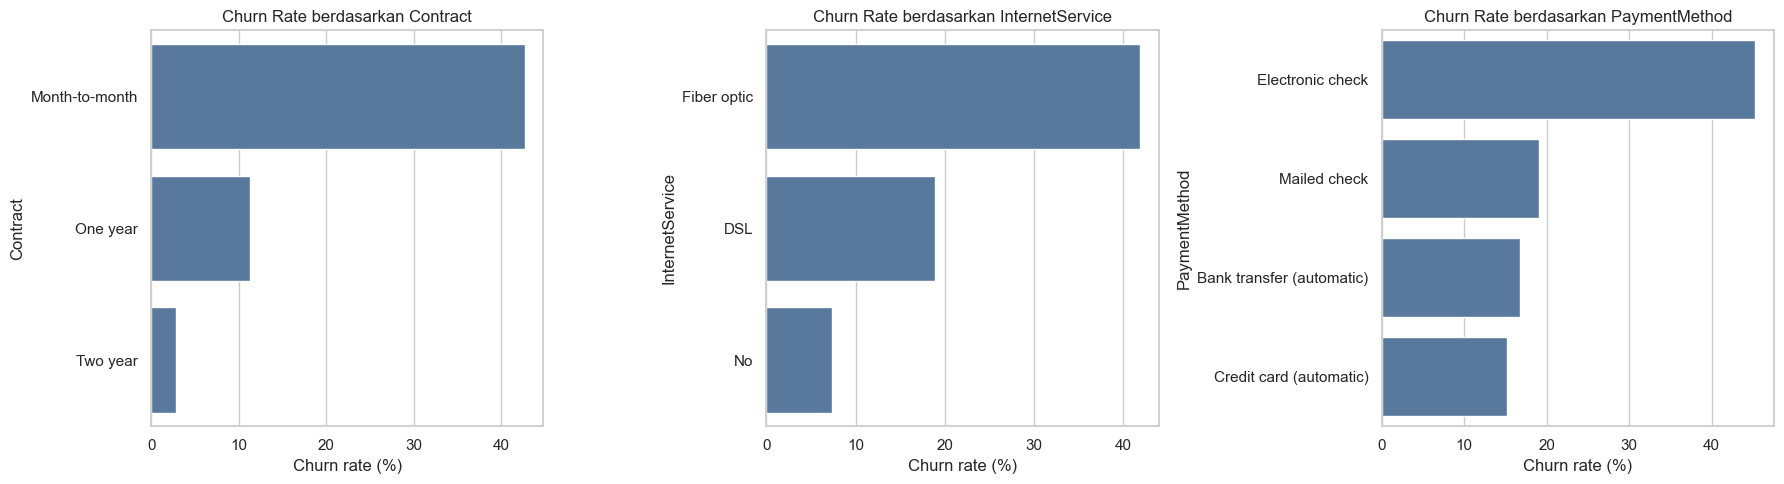

In [5]:
categorical_features_for_eda = ["Contract", "InternetService", "PaymentMethod"]

for column in categorical_features_for_eda:
    print(f"Distribusi {column}:")
    summary = pd.DataFrame({
        "count": df_eda[column].value_counts(),
        "percentage": df_eda[column].value_counts(normalize=True).mul(100).round(2),
    })
    display(summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column in zip(axes, categorical_features_for_eda):
    churn_rate = (
        df_eda.groupby(column)["Churn"]
        .apply(lambda values: (values == "Yes").mean())
        .sort_values(ascending=False)
        .mul(100)
    )
    sns.barplot(x=churn_rate.values, y=churn_rate.index, ax=ax, color="#4C78A8")
    ax.set_title(f"Churn Rate berdasarkan {column}")
    ax.set_xlabel("Churn rate (%)")
    ax.set_ylabel(column)
plt.tight_layout()
plt.show()

**Insight EDA:**

- Target `Churn` tidak seimbang sempurna; pelanggan dengan `Churn = No` lebih banyak dibanding `Churn = Yes`, sehingga evaluasi model perlu menggunakan metrik seperti precision, recall, F1-score, dan ROC-AUC, bukan hanya accuracy.
- `TotalCharges` perlu dikonversi ke numerik karena nilai kosong pada dataset mentah menjadi missing value setelah konversi. Missing value ini perlu ditangani melalui imputasi.
- Fitur numerik `tenure`, `MonthlyCharges`, dan `TotalCharges` relevan karena menggambarkan lama pelanggan bertahan dan besar tagihan. Polanya dapat berbeda antara pelanggan churn dan tidak churn.
- Fitur kategorikal seperti `Contract`, `InternetService`, dan `PaymentMethod` berpotensi kuat memengaruhi churn. Contohnya, tipe kontrak bulanan biasanya lebih berisiko churn dibanding kontrak jangka panjang.
- Karena terdapat campuran fitur numerik dan kategorikal, preprocessing perlu menggunakan pipeline berbeda untuk masing-masing tipe fitur.

# **5. Data Preprocessing**

Preprocessing pada notebook ini dibuat konsisten dengan script produksi `preprocess.py`. Langkah utamanya adalah menghapus `customerID`, memetakan target `Churn`, melakukan train-test split dengan stratifikasi, lalu membuat pipeline numerik dan kategorikal. Preprocessor hanya di-*fit* pada `X_train` untuk mencegah data leakage.

In [6]:
df_model = df.copy()
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce")

TARGET_COLUMN = "Churn"
DROP_COLUMNS = ["customerID"]
RANDOM_STATE = 42
TEST_SIZE = 0.2

y = df_model[TARGET_COLUMN].map({"No": 0, "Yes": 1}).astype(int)
X = df_model.drop(columns=[TARGET_COLUMN, *DROP_COLUMNS], errors="ignore")

numeric_columns = X.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = X.select_dtypes(exclude=["number"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_columns),
        ("cat", categorical_pipeline, categorical_columns),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out().tolist()

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

print("Kolom numerik:", numeric_columns)
print("Kolom kategorikal:", categorical_columns)
print("Shape X_train sebelum preprocessing:", X_train.shape)
print("Shape X_test sebelum preprocessing:", X_test.shape)
print("Shape X_train setelah preprocessing:", X_train_processed_df.shape)
print("Shape X_test setelah preprocessing:", X_test_processed_df.shape)

print("\nDistribusi target original/train/test:")
display(pd.DataFrame({
    "original": y.value_counts(normalize=True).sort_index(),
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
}).rename(index={0: "No", 1: "Yes"}))

print("Contoh 25 feature_names pertama:")
display(feature_names[:25])

print("Contoh hasil preprocessing:")
display(X_train_processed_df.head())

print(f"Preprocessing produksi/reproducible tersedia di: {PRODUCTION_PREPROCESS_SCRIPT}")

Kolom numerik: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Kolom kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape X_train sebelum preprocessing: (5634, 19)
Shape X_test sebelum preprocessing: (1409, 19)
Shape X_train setelah preprocessing: (5634, 45)
Shape X_test setelah preprocessing: (1409, 45)

Distribusi target original/train/test:


,original,train,test
Churn,,,
No,0.73463,0.734647,0.734564
Yes,0.26537,0.265353,0.265436


Contoh 25 feature_names pertama:


['num__SeniorCitizen',
 'num__tenure',
 'num__MonthlyCharges',
 'num__TotalCharges',
 'cat__gender_Female',
 'cat__gender_Male',
 'cat__Partner_No',
 'cat__Partner_Yes',
 'cat__Dependents_No',
 'cat__Dependents_Yes',
 'cat__PhoneService_No',
 'cat__PhoneService_Yes',
 'cat__MultipleLines_No',
 'cat__MultipleLines_No phone service',
 'cat__MultipleLines_Yes',
 'cat__InternetService_DSL',
 'cat__InternetService_Fiber optic',
 'cat__InternetService_No',
 'cat__OnlineSecurity_No',
 'cat__OnlineSecurity_No internet service',
 'cat__OnlineSecurity_Yes',
 'cat__OnlineBackup_No',
 'cat__OnlineBackup_No internet service',
 'cat__OnlineBackup_Yes',
 'cat__DeviceProtection_No']

Contoh hasil preprocessing:


,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__PhoneService_No,cat__PhoneService_Yes,cat__MultipleLines_No,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,cat__InternetService_DSL,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_No,cat__OnlineSecurity_No internet service,cat__OnlineSecurity_Yes,cat__OnlineBackup_No,cat__OnlineBackup_No internet service,cat__OnlineBackup_Yes,cat__DeviceProtection_No,cat__DeviceProtection_No internet service,cat__DeviceProtection_Yes,cat__TechSupport_No,cat__TechSupport_No internet service,cat__TechSupport_Yes,cat__StreamingTV_No,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,-0.441773,0.102371,-0.521976,-0.263290,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.441773,-0.711743,0.337478,-0.504815,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.441773,-0.793155,-0.809013,-0.751214,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.441773,-0.263980,0.284384,-0.173700,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,-0.441773,-1.281624,-0.676279,-0.990851,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Preprocessing produksi/reproducible tersedia di: D:\Learn\Dicoding\Pijak\Membangun Sistem Machine Learning\submission\Eksperimen_SML_Agung_Trisutaji_Aprian\Membangun_model\telco_customer_churn_preprocessing\preprocess.py


Preprocessing di atas mengikuti alur yang sama dengan script produksi:

```text
Membangun_model/telco_customer_churn_preprocessing/preprocess.py
```

Script tersebut digunakan untuk menghasilkan data train/test terproses, `feature_names.json`, `preprocessing_summary.json`, dan artifact `preprocessor.pkl` yang dipakai oleh proses modelling serta serving API.